In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

In [15]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1UyarN42OoNKKdSS_7j12P2iwOLZGs2to")

In [16]:
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [18]:
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [19]:
df.isnull().sum()

,0
magnitude,0
cdi,0
mmi,0
sig,0
nst,0
dmin,0
gap,0
depth,0
latitude,0
longitude,0


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
# Buat peta dasar Indonesia
peta = folium.Map(location=[0, 0], zoom_start=2)

# Buat list data [lat, long, value] untuk heatmap
data_heatmap = df[['latitude', 'longitude', 'magnitude']].values.tolist()

# Tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=12, blur=15, max_zoom=6).add_to(peta)

# Tampilkan peta
peta

In [22]:
normalisasi_df = df.drop(columns=['Year','Month', 'tsunami'])

In [23]:
from scipy.stats import shapiro
stat, p = shapiro(normalisasi_df)

print("Statik: ", stat)
print("P-value: ", p)

if p > 0.05:
    print("Data berdistribusi normal (tidak tolak H0)")
else:
    print("Data tidak berdistribusi normal (tolak H0)")

Statik:  0.5540226040335624
P-value:  1.350666858824841e-88
Data tidak berdistribusi normal (tolak H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7820.
  res = hypotest_fun_out(*samples, **kwds)


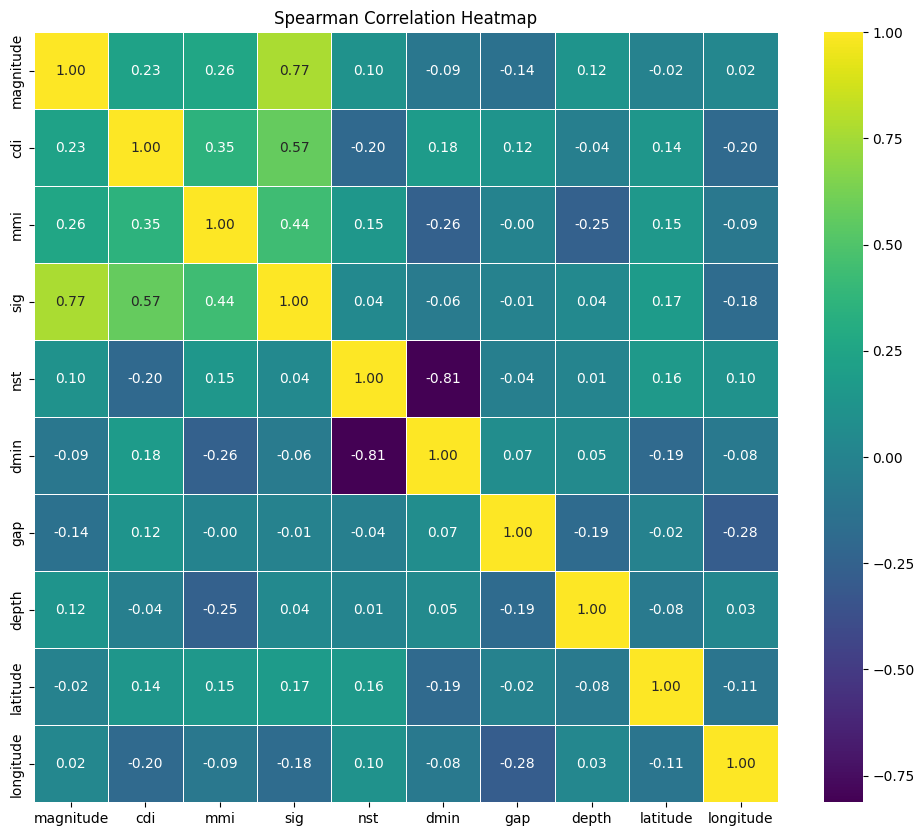

In [24]:
correlation_df = normalisasi_df

correlation_matrix = correlation_df.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

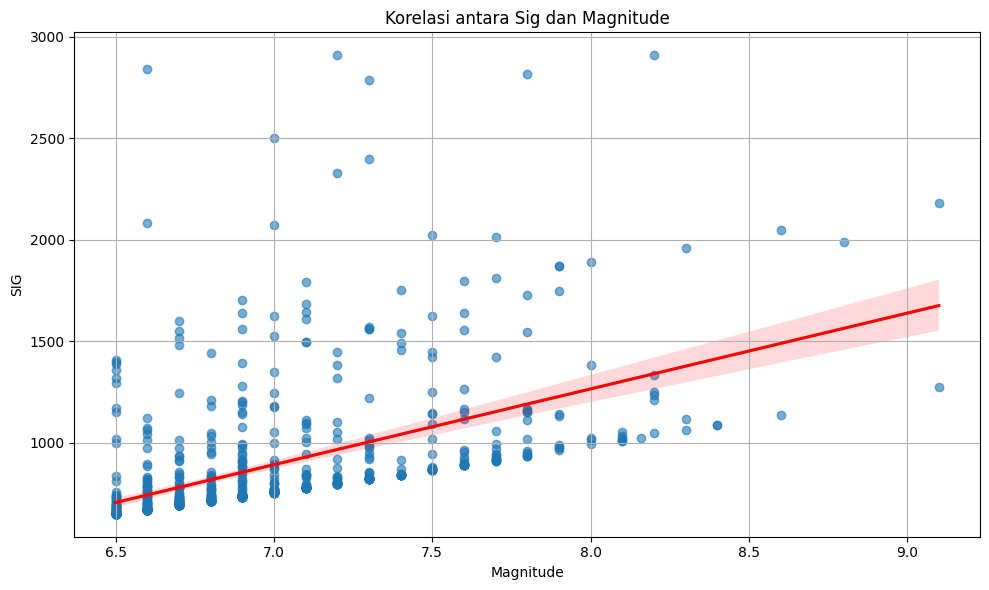

In [25]:
plt.figure(figsize=(10, 6))
sns.regplot(
    x="magnitude",
    y="sig",
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={"color": "red"}
)

plt.title("Korelasi antara Sig dan Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("SIG")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import RobustScaler

column_names = normalisasi_df.columns
scaler = RobustScaler()
normalisasi_df = scaler.fit_transform(normalisasi_df)
normalisasi_df = pd.DataFrame(normalisasi_df, columns=column_names)
normalisasi_df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude
0,0.4,0.428571,0.5,0.064000,-0.051685,0.273215,-0.195122,-0.343916,-0.184045,0.227416
1,0.2,-0.142857,-1.0,-0.086857,-0.092135,1.196457,0.910569,-0.036224,-0.060723,-0.039382
2,0.4,-0.285714,-1.5,0.004571,0.015730,1.677402,-0.130081,15.460280,-0.445306,-1.304443
3,1.0,0.000000,-0.5,0.361143,0.020225,1.001074,0.065041,0.299441,-0.425968,-1.276262
4,-0.4,-0.714286,-2.0,-0.384000,-0.020225,2.682770,0.455285,16.732000,-0.586554,0.312100


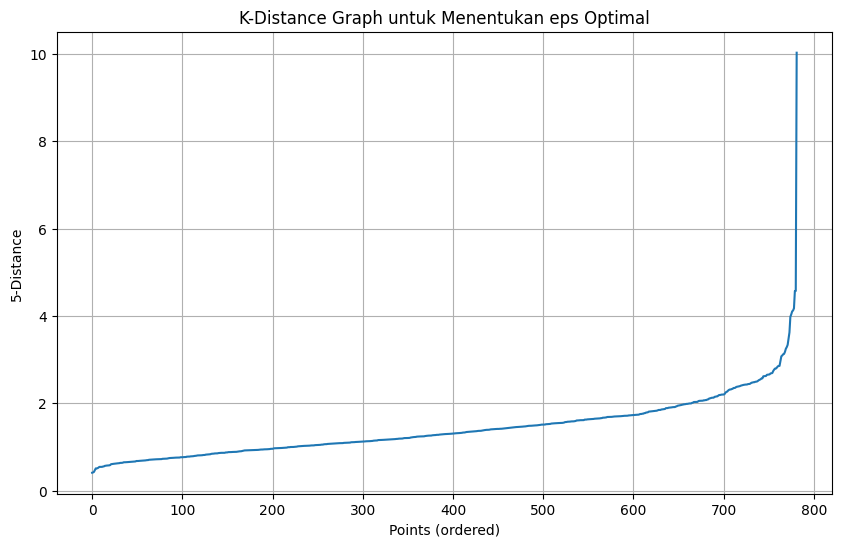

In [27]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Gunakan data hasil normalisasi
X = normalisasi_df.values

# Tentukan jumlah tetangga (min_samples biasanya = 4-10)
k = 5

# Fit nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Ambil jarak tetangga ke-k (k-distance)
k_distances = np.sort(distances[:, k-1])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("K-Distance Graph untuk Menentukan eps Optimal")
plt.ylabel(f"{k}-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()

In [28]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)
labels = dbscan.fit_predict(normalisasi_df.values)

df["Cluster_DBSCAN"] = labels
print(df["Cluster_DBSCAN"].value_counts())

Cluster_DBSCAN
 0    716
 1     49
-1     17
Name: count, dtype: int64


In [29]:
# Buat peta dasar Indonesia
peta = folium.Map(location=[0, 0], zoom_start=2)

# Buat list data [lat, long, value] untuk heatmap
data_heatmap = df[['latitude', 'longitude', 'magnitude']].values.tolist()

# Tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=12, blur=15, max_zoom=6).add_to(peta)

# Tampilkan peta
peta

In [30]:
from sklearn.metrics import silhouette_score

mask = labels != -1 # hilangkan noise

score = silhouette_score(normalisasi_df[mask], labels[mask])

print("Silhouette Score:", score)

Silhouette Score: 0.7425117373767659


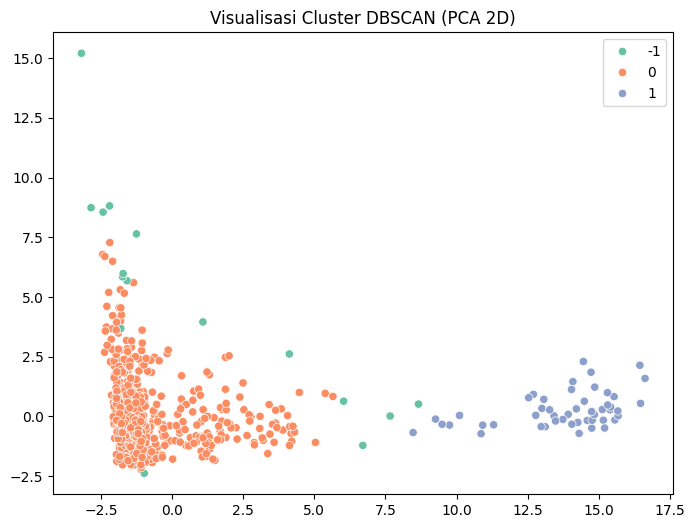

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns # Asumsi sns sudah diimpor

pca = PCA(n_components=2)
reduced = pca.fit_transform(normalisasi_df)

plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette="Set2")
plt.title("Visualisasi Cluster DBSCAN (PCA 2D)")
plt.show()

In [32]:
def klasifikasi_db(x):
    if x == 0:
        return "Baik"
    elif x == -1:
        return "Noise"
    else:
        return "Kurang"

df['Klasifikasi_DBSCAN'] = df['Cluster_DBSCAN'].apply(klasifikasi_db)

print(df['Klasifikasi_DBSCAN'].value_counts())

Klasifikasi_DBSCAN
Baik      716
Kurang     49
Noise      17
Name: count, dtype: int64


In [33]:
# Data untuk hover
import plotly.express as px

df_pca_db = pd.DataFrame(reduced, columns=["PCA 1", "PCA 2"])
df_pca_db["Klasifikasi_DBSCAN"] = df["Klasifikasi_DBSCAN"].values
df_pca_db["Year"] = df["Year"].values

# Plotly interaktif
fig = px.scatter(
    df_pca_db,
    x="PCA 1",
    y="PCA 2",
    color="Klasifikasi_DBSCAN",
    hover_name="Year",
    title="Persebaran Data Berdasarkan Klasifikasi (DBSCAN)",
    width=1500,
    height=900
)

fig.show()